# **Interpolazione polinomiale**

Lo scopo delle tecniche di interpolazione è quello di ricavare, in forma chiusa, una relazione del tipo $y=p(x)$ che catturi alcune coppie di punti $(x_{1},y_{1}),\dots,(x_{n}, y_{n})$. Tipicamente, questo problema risulta di interesse in due contesti:

*   Approssimazione di funzioni: si vuole approssimare una funzione $f$ nota con un'espressione più semplice, ad esempio in vista del calcolo numerico (si veda calcolo di integrali!).
*   Approssimazione di dati: si vuole ricostruire l'andamento di alcuni dati (ad esempio provenienti da osservazioni sperimentali, oppure dal campionamento di una funzione $f$ non nota).

Strettamente parlando, si parla di *interpolazione* se a partire dai punti viene proposta una funzione $\tilde{p}$ che passa **esattamente** dai dati sperimentali, cioè
</br></br>
\begin{equation*}y_{i}=\tilde{p}(x_{i})\quad\quad\forall i = 1,\dots, n
\end{equation*}
</br>
Si parla invece di _approssimazione ai minimi quadrati_ se l'obiettivo è quello di trovare una funzione $\hat{p}$ che minimizzi lo scarto quadratico
</br></br>
\begin{equation*}
\sum_{i=1}^{n}|y_{i}-\hat{p}(x_{i})|^{2}
\end{equation*}
</br>
all'interno di una "classe di possibili funzioni".

Oggi ci focalizzaremo su tre tipologie di interpolazione e approssimazione:

  1. Interpolazione polinomiale di Lagrange, dove $\tilde{p}$ è un polinomio di grado $n-1$
  2. Interpolazione composita (spline), dove $\tilde{p}$ è un polinomio di grado $k$ _a tratti_ (es: spezzata/spline cubica)
  3. Approssimazione polinomiale (minimi quadrati), dove $\hat{p}$ è un polinomio di grado $k<n-1$.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

## **Esercizio 1: Interpolazione per l'approssimazione di funzioni**

L'interpolazione polinomiale può essere utilizzata per approssimare una data funzione $f: [a,b]\to\mathbb{R}$. In questo caso, si valuta $f$ su di una griglia con $n+1$ nodi, $\{x_{0},\dots,x_{n}\}\subset[a,b]$ e la si approssima con l'interpolante $\tilde{p}=\Pi_{n}f$ passante per i nodi $\{(x_{i}, f(x_{i}))\}_{i=0}^{n}$.
La notazione $\Pi_{n}f$ sta ad enfatizzare che l'interpolante dipende dalla funzione $f$ e dal numero di intervalli della partizione $n$.
</br></br>
La qualità dell'approssimazione può essere indagata a posteriori valutando l'errore globale
</br></br>
\begin{equation*}
E_{n}:=\max_{x\in[a,b]}|f(x)-\Pi_{n}f(x)|
\end{equation*}
</br>
sull'intervallo $[a,b]$. Come vedremo, nel caso di interpolazione polinomiale di Lagrange, la numerosità dei nodi non basta a garantire una buona approssimazione: occorre anche posizionare i nodi in modo opportuno!

<mark>**Esercizio 1.1**</mark></br>
Si consideri la funzione (chiamata **funzione di Runge**)
</br></br>
\begin{equation*}
f(x)=\frac{1}{1+x^{2}},
\end{equation*}
</br>
sull'intervallo $[a,b]=[-5,5]$. Si discuta la possibilità di interpolare $f(x)$ tramite polinomi di Lagrange. Questo può essere fatto utilizzando le funzioni **polyfit** e **polyval** della libreria **numpy**.

Si cominci rappresentando la funzione $f(x)$ e le funzioni della base di Lagrange $\mathcal{L}_i (x), i=0,...,n$. Si consideri un polinomio di interpolazione di grado 3.

In [ ]:
#n=grado del polinomio interpolante
#n+1=numero nodi della griglia di interpolazione -> n=numero sottointervalli in cui si divide l'intervallo principale

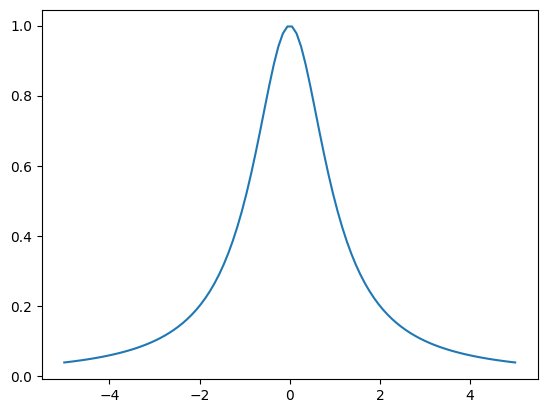

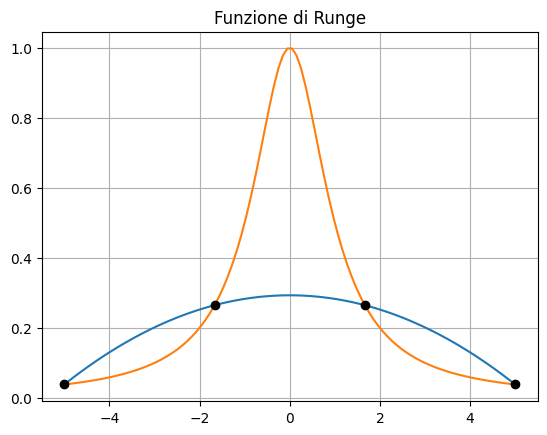

In [3]:
#prova da sola
f=lambda x: 1/(1+x**2)
#creazione dell'intervallo di punti
a=-5
b=5
xgrid=np.linspace(a, b, 100)
#rappresentazione di f
plt.figure()
plt.plot(xgrid, f(xgrid))
plt.show()

#costruzione base di lagrange considerando un polinomio di interpolazione di grado 3
from numpy import polyfit
from numpy import polyval

#costruzione griglia dei nodi e valore della f in tali nodi
n=3
x_nodi=np.linspace(a, b, n+1)
y_nodi=f(x_nodi)

p=polyfit(x_nodi, y_nodi, n) #costruisce il polinomio di lagrange che approssima la funzione, e vuole come input: x, y, grado polinomiale
y=polyval(p, xgrid) #tale funzione prende in input il polinomio, valutato nella griglia di punti xgrid costruita prima

plt.plot(xgrid, y)
plt.plot(xgrid, f(xgrid))
plt.plot(x_nodi, y_nodi, 'ko')
plt.title("Funzione di Runge")
plt.grid()
plt.show()




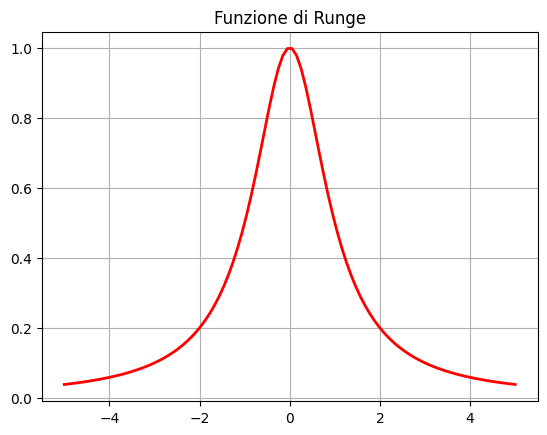

In [ ]:
# Definizione di f (tramite lambda function)
f = lambda x: 1.0/(1+x**2)

# Creazione dell'intervallo di punti
a = -5
b = 5
x_grid = np.linspace(a, b, 100)

# Rappresentazione di f
plt.figure()
plt.plot(x_grid, f(x_grid), 'r-', linewidth=2)
plt.title("Funzione di Runge")
plt.grid()
plt.show()

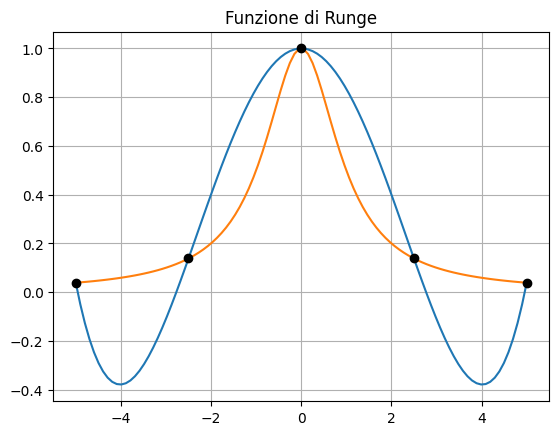

In [ ]:
from numpy import polyfit, polyval

#Esempio di interpolazione polinomiale di Lagrange con grado n=4 usando n+1 nodi equispaziati sull'intervallo [a,b].

x_nodi=np.linspace(a, b, 5)
y_nodi=f(x_nodi)

p=polyfit(x_nodi, y_nodi, 4) #costruisce il polinomio di lagrange che approssima la funzione, e vuole come input: x, y, grado polinomiale
y=polyval(p, x_grid) #tale funzione prende in input il polinomio, valutato nella griglia di punti x_grid costruita prima

plt.plot(x_grid, y)
plt.plot(x_grid, f(x_grid))
plt.plot(x_nodi, y_nodi, 'ko')
plt.title("Funzione di Runge")
plt.grid()
plt.show() 
#il grafico restituisce in arancione la funzione da interpolare e in azzurro la funzione interpolante/la sua approssimazione


Vediamo meglio cosa si nasconde dietro i comandi polyfit e polyval...

L'interpolante polinomiale di Lagrange di grado $n$ passante per $(x_i, y_i)$ con $i=0,...,n$ è definita come:

\begin{equation}
p_n(x) = \sum_{i=0}^{n} y_i \mathcal{L}_i(x),
\end{equation}

dove $\mathcal{L}_i$ costituiscono la base di Lagrange.

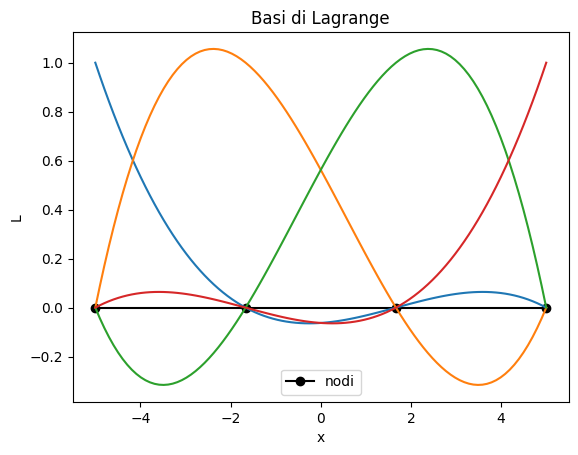

In [4]:
# Esempio della costruzione della base di Lagrange con grado n=3 usando n+1 nodi equispaziati sull'intervallo [a,b].

# grado del polinomio
n=3
# estremi dell'intervallo
a=-5
b=5
# numero dei nodi (grado polinomiale n + 1)
n_nodi=n+1
# nodi nell'intervallo
x_nodi=np.linspace(a, b, n_nodi)

# punti dove valutiamo il polinomio per la rappresentazione grafica
x_grid = np.linspace(a, b, 100)

plt.figure()
plt.plot(x_nodi, np.zeros(n_nodi), 'ko-', label = 'nodi') #nodi equispaziati tra a e b, punti neri nel grafico, sull'asse x

# costruzione delle funzioni di base e rappresentazione
for i in range(n_nodi):
    y_nodi=np.zeros(n_nodi)
    y_nodi[i]=1 #la base i-esima vale 1 nel nodo i e 0 altrove
   
    p=polyfit(x_nodi, y_nodi, n)
    L=lambda x: polyval(p, x) #per valutare la base i-esima/il polinomio nella griglia di punti/di nodi GENERICA
    #oppure, come prima: y=polyval(p, x_grid), invece di creare la variabile intermedia L (la differenza è nel fatto che L
    #valuta in generale il polinomio di lagrange nella generica griglia di nodi, mentre y lo valuta nella griglia creata, x_grid)
    plt.plot(x_grid, L(x_grid))
   

plt.title("Basi di Lagrange")
plt.legend()
plt.xlabel("x")
plt.ylabel("L")
plt.show()

<mark>**Esercizio 1.2**</mark></br>

Si approssimi $f$ usando l'interpolazione polinomiale di Lagrange su di una griglia equispaziata con $n=7,9,11$ intervalli. Confrontare graficamente la funzione $f$ con le varie interpolanti. Calcolare inoltre gli errori $E_{n}$ dei polinomi interpolanti rispetto alla funzione esatta.

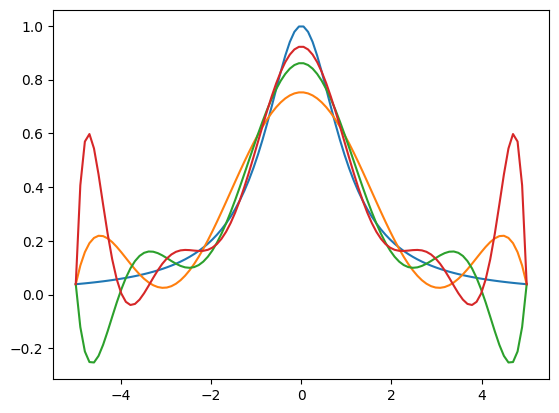

In [5]:
#prova da sola
n_list=[7, 9, 11] #numero intervalli assunti nel ciclo
#inizializzo l'errore
err=[]
plt.figure()
plt.plot(x_grid, f(x_grid))

for i in n_list:
    x_nodi=np.linspace(a, b, i+1)
    y_nodi=f(x_nodi)
    p=polyfit(x_nodi, y_nodi, i)
    y=polyval(p, x_grid)
    plt.plot(x_grid, y)
    err.append(np.linalg.norm(f(x_grid)-y))

plt.show()



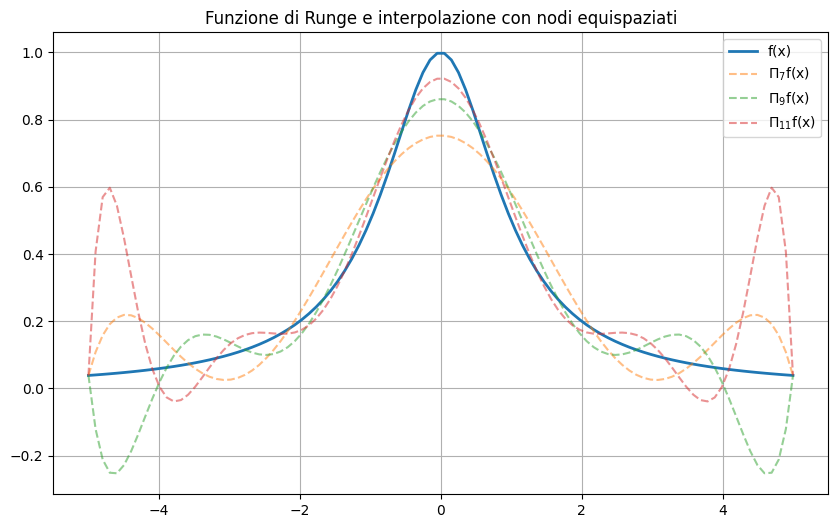

In [ ]:
num_intervalli = [7, 9, 11]
#prima apro la figura, rappresento la x_grid e la funzione di runge, e solo dopo entro nel ciclo for, così da
#sovrapporre al primo grafico creato al di fuori del ciclo for quelli creati all'interno del ciclo

#creo la lista vuota/inizializzazione della lista degli errori
err=[]

plt.figure(figsize = (10,6))
plt.plot(x_grid, f(x_grid), linewidth=2, label='f(x)')
plt.title("Funzione di Runge e interpolazione con nodi equispaziati")
plt.grid()

# Costruzione delle interpolanti e rappresentazione (n intervalli -> n+1 nodi)
for n in num_intervalli: 
    x_nodi=np.linspace(a, b, n+1)
    y_nodi=f(x_nodi)

    p=polyfit(x_nodi, y_nodi, n)
    y=polyval(p, x_grid)
    plt.plot(x_grid, y, '--', label = '$\\Pi_{%d}$f(x)' %n, alpha = 0.5)
    err.append(np.linalg.norm(f(x_grid)-y))


plt.legend()
plt.show()

<mark>**Domanda**</mark></br>
Che cosa sta succedendo all'aumentare di $n$? Perchè osserviamo queste oscillazioni? Discutere quello che è anche noto come **fenomeno di Runge**.

In [ ]:
#All'aumentare del grado polinomiale (e quindi anche all'aumentare dei nodi della griglia), sebbene al centro 
#ci si stia avvicinando alla funzione da approssimare agli estremi, nella funzione di Runge, si verifica il fenomeno di Runge, in quando agli estremi
#si hanno delle oscillazioni, legate al fatto che si stanno usando dei nodi equispaziati, e 
#la costante di Lebesgue esplode all'aumentare del grado polinomiale. Questa NON convergenza emerge dalla
#stampa degli errori, come segue:
err

[np.float64(1.0243855660793015),
 np.float64(1.090352974101346),
 np.float64(1.6331550040881773)]

<mark>**Esercizio 1.3**</mark></br>
Si ripeta il punto precedente, utilizzando questa volta i nodi di Chebyshev. Si rammenta che, scelto $n$, sull'intervallo $\hat{I}=[-1,1]$, essi sono dati da
</br></br>
\begin{equation*}
\hat{x}_{i}=-\cos\left(\frac{\pi i}{n}\right),
\end{equation*}
</br>
dove $i=0,\dots,n$. I nodi possono essere trasferiti su un generico intervallo $[a,b]$ con la trasformazione
</br></br>
$$x_{i}=\frac{a+b}{2}+\frac{b-a}{2}\hat{x}_{i}.$$
</br>

In [ ]:
def nodi_Chebyshev(a, b, n):
  """
  Calcolo degli n+1 nodi di Chebyshev sull'intervallo [a,b]
  Input:
  a: estremo sinistro dell'intervallo
  b: estremo destro dell'intervallo
  n: numero di intervalli (n+1 nodi) pari al grado del polinomio approssimante/interpolante
  Output:
  x: nodi di Chebyshev
  """
  x_cgl=[]
  x_old=-np.cos((np.pi*i)/n) #è x con cappuccio
  
  for i in range(n):
    x_new=(a+b)*0.5 + (b-a)*0.5*x_old #nodi di chebichev sul generico intervallo
    x_cgl.append(x_new)

  return x_cgl

#oppure
def nodi_Chebyshev(a, b, n):
  i=np.arange(n+1) #i da 0 a n -> con arange devo fare n+1 per INCLUDERE n, dal momento che arange esclude l'ultimo estremo
  x_old=-np.cos((np.pi*i)/n)
  x_new=(a+b)*0.5 + (b-a)*0.5*x_old

  return x_new


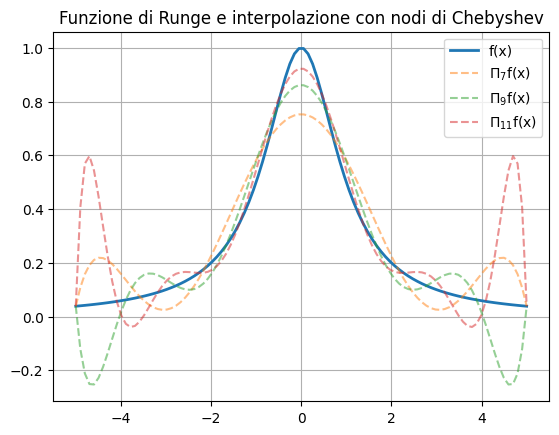

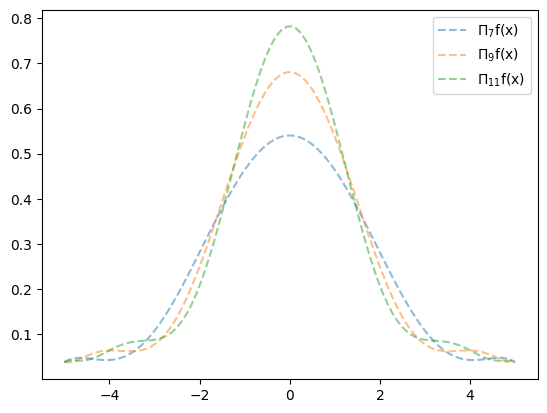

In [ ]:
num_intervalli = [7, 9, 11]

err=[]

plt.figure()
plt.plot(x_grid, f(x_grid), linewidth=2, label='f(x)')
plt.title("Funzione di Runge e interpolazione con nodi di Chebyshev")
plt.grid()

# Costruzione delle interpolanti e rappresentazione (n intervalli -> n+1 nodi)
for n in num_intervalli: 
    x_nodi=np.linspace(a, b, n+1)
    y_nodi=f(x_nodi)

    p=polyfit(x_nodi, y_nodi, n)
    y=polyval(p, x_grid)
    plt.plot(x_grid, y, '--', label = '$\\Pi_{%d}$f(x)' %n, alpha = 0.5)
    err.append(np.linalg.norm(f(x_grid)-y))


plt.legend()
plt.show()


# Costruzione delle interpolanti e rappresentazione (n intervalli -> n+1 nodi) con nodi cgl
for n in num_intervalli: 
    x_nodi=nodi_Chebyshev(a, b, n)
    y_nodi=f(x_nodi)

    p=polyfit(x_nodi, y_nodi, n)
    y=polyval(p, x_grid)
    plt.plot(x_grid, y, '--', label = '$\\Pi_{%d}$f(x)' %n, alpha = 0.5)
    err.append(np.linalg.norm(f(x_grid)-y))


plt.legend()
plt.show()

In presenza di nodi equispaziati, l'interpolazione polinomiale può soffrire problemi di stabilità e convergenza. Due possibili soluzioni sono date da:

*   Nodi di interpolazione non equispaziati
*   Interpolazione composita (spline) -> la vediamo applicata all'esercizio 2



## **Esercizio 2: Interpolazione per l'approsimazione di dati**
Nella tabella qui sotto riportata vengono elencati i risultati di un
esperimento eseguito per individuare il legame tra lo *sforzo* $\sigma$ e la relativa *deformazione* $\varepsilon$.
</br></br>
\begin{equation}
\begin{matrix}
\text{test}\ & \sigma \ [{\rm MPa}] & \varepsilon [\text{cm}/\text{cm}]\\
    1 & 0.00 & 0.00 \\
    2 & 0.06 & 0.08 \\
    3 & 0.14 & 0.14 \\
    4 & 0.25 & 0.20 \\
    5 & 0.31 & 0.23 \\
    6 & 0.47 & 0.25 \\
    7 & 0.60 & 0.28 \\
    8 & 0.70 & 0.29 \\
  \end{matrix}
\end{equation}
</br>
A partire da questi dati (utilizzando opportune tecniche di interpolazione e approssimazione) si vuole stimare la deformazione $ɛ$ in corrispondenza dei valori di sforzo per cui non si ha a disposizione un dato sperimentale.


<mark>**Esercizio 2.1: rappresentazione grafica dei dati**</mark></br>
Rappresentare i dati graficamente.

In [8]:
# sigma ed epsilon
sigma = [0.00, 0.06, 0.14, 0.25, 0.31, 0.47, 0.60, 0.70]
epsilon = [0.00, 0.08, 0.14, 0.20, 0.23, 0.25, 0.28, 0.29]

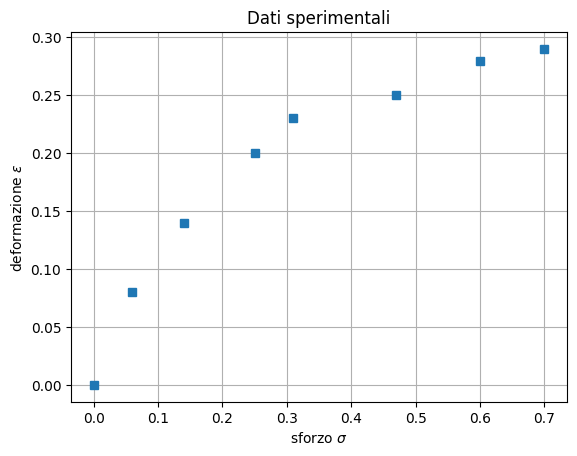

In [9]:
# Rappresentare i dati in un grafico sforzo vs deformazione
plt.figure()
plt.plot(sigma, epsilon, 's')
plt.xlabel("sforzo $\\sigma$")
plt.ylabel("deformazione $\\varepsilon$")
plt.title("Dati sperimentali")
plt.grid()
plt.show()

<mark>**Esercizio 2.2: interpolazione polinomiale**</mark></br>
Calcolare l'interpolante polinomiale di Lagrange, quindi confrontarla con i dati sperimentali.

**Nota**: Si rammenti che un polinomio di Lagrange interpolante $n$ dati ha grado $n-1$.

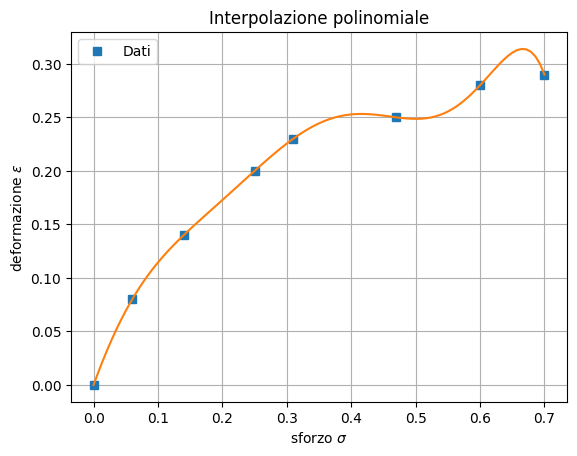

In [10]:
# Interpolazione di Lagrange e rappresentazione grafica

n=len(sigma)
p=polyfit(sigma, epsilon, n-1)

interp_lagrange=lambda x: polyval(p, x)

x_grid=np.linspace(min(sigma), max(sigma), 100)

plt.figure()
plt.plot(sigma, epsilon, 's', label='Dati')
plt.plot(x_grid, interp_lagrange(x_grid))
plt.xlabel("sforzo $\\sigma$")
plt.ylabel("deformazione $\\varepsilon$")
plt.title("Interpolazione polinomiale")
plt.legend()
plt.grid()


<mark>**Esercizio 2.3: spline lineare**</mark></br>
Confrontare i dati sperimentali con la loro interpolante lineare a tratti (spline lineare). Si sfrutti la funzione $\texttt{interp}$ della libreria $\texttt{numpy}$.

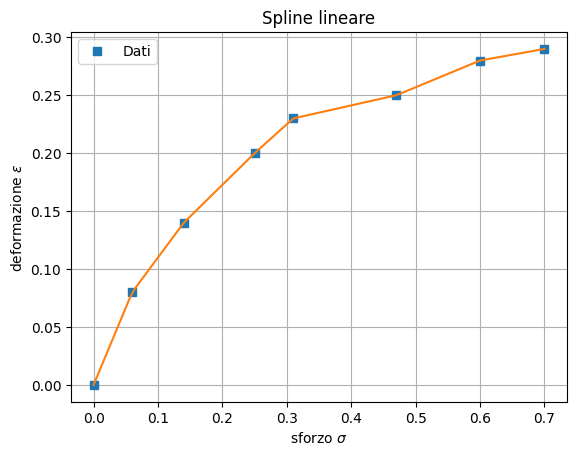

In [11]:
from numpy import interp

# Interpolazione composita (spline lineare) e rappresentazione
spline_lineare=lambda x: interp(x, sigma, epsilon) #tale funzione unisce sostanzialmente polyfit e polyval, con una sintassi diversa

plt.figure()
plt.plot(sigma, epsilon, 's', label='Dati')
plt.plot(x_grid, spline_lineare(x_grid))
plt.xlabel("sforzo $\\sigma$")
plt.ylabel("deformazione $\\varepsilon$")
plt.title("Spline lineare")
plt.legend()
plt.grid()


In [ ]:

#dai grafici, per i dati esaminati, risulta migliore l'approssimazione con la spline lineare rispetto al polinomio di lagrange (vedi
#oscillazione nell'ultimo intervallo)

<mark>**Esercizio 2.4: spline cubica**</mark></br>
Confrontare i dati sperimentali con la loro interpolante cubica a tratti (spline cubica). Si sfrutti la classe $\texttt{CubicSpline}$ presente nel modulo $\texttt{scipy.interpolate}$.

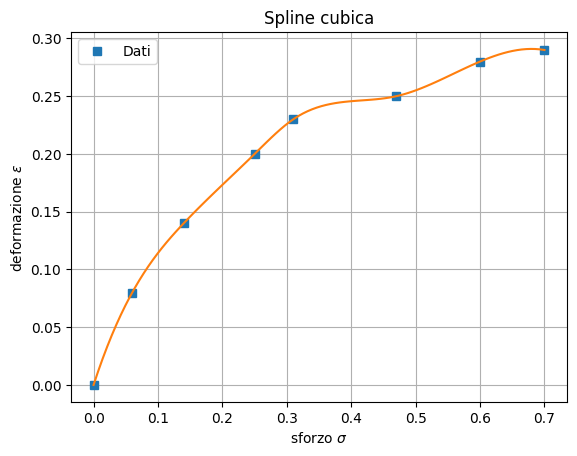

In [12]:
from scipy.interpolate import CubicSpline
spline_cubica=CubicSpline(sigma, epsilon) #restituisce già una lambda function, quindi basta fare funzione(sigma, epsilon), a differenza di quanto fa
#interp usato per la spline lineare

# Interpolazione composita (spline cubica) e rappresentazione grafica
plt.figure()
plt.plot(sigma, epsilon, 's', label='Dati')
plt.plot(x_grid, spline_cubica(x_grid))
plt.xlabel("sforzo $\\sigma$")
plt.ylabel("deformazione $\\varepsilon$")
plt.title("Spline cubica")
plt.legend()
plt.grid()

In [ ]:
#tale interpolazione risulta ancora migliore di quella lineare composita

<mark>**Esercizio 2.5: approssimazione nel senso dei minimi quadrati**</mark></br>

Dati $n+1$ punti distinti $(x_i, y_i)$, l'approssimazione ai minimi quadrati cerca il polinomio $\hat{p}$ di grado $1<m<n$ che minimizza la distanza dai dati, ovvero tale che:

\begin{equation}
\sum_{i=0}^{n} (y_i - \hat{p}(x_i))^2 \le \sum_{i=0}^{n} (y_i - p_m(x_i))^2
\end{equation}

Confrontare i dati sperimentali con il corrispondente polinomio di grado 4 che approssima i dati nel senso dei minimi quadrati. Si sfruttino nuovamente le funzioni $\texttt{polyfit}$ e $\texttt{polyval}$ di $\texttt{numpy}$, facendo attenzione all'argomento $\texttt{deg}$.

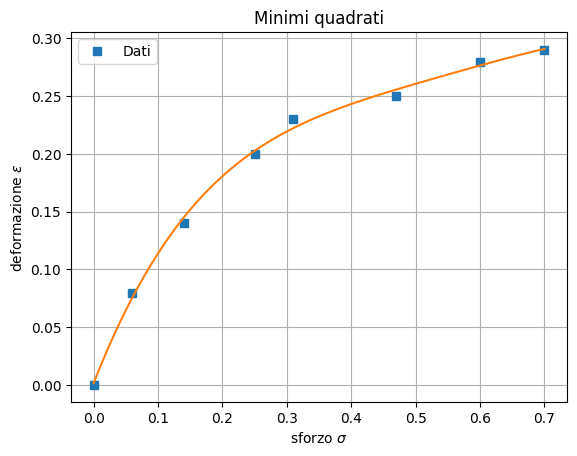

In [13]:
# Approssimazione ai minimi quadrati e rappresentazione grafica

deg=4 #è MINORE del grado del polinomio di lagrange!!!

p_minq=polyfit(sigma, epsilon, deg)
minq=lambda x: polyval(p_minq, x)

plt.figure()
plt.plot(sigma, epsilon, 's', label='Dati')
plt.plot(x_grid, minq(x_grid))
plt.xlabel("sforzo $\\sigma$")
plt.ylabel("deformazione $\\varepsilon$")
plt.title("Minimi quadrati")
plt.legend()
plt.grid()

In [ ]:
#polinomio globale di grado 4 che è il migliore, il più vicino ai miei dati, ma che NON passa per questi, ma ne approssima l'andamento!!!

<mark>**Esercizio 2.6: confronto globale**</mark></br>

Confrontare, in un unico grafico, i dati sperimentali con tutte le interpolanti e approssimanti. Si commentino i risultati.

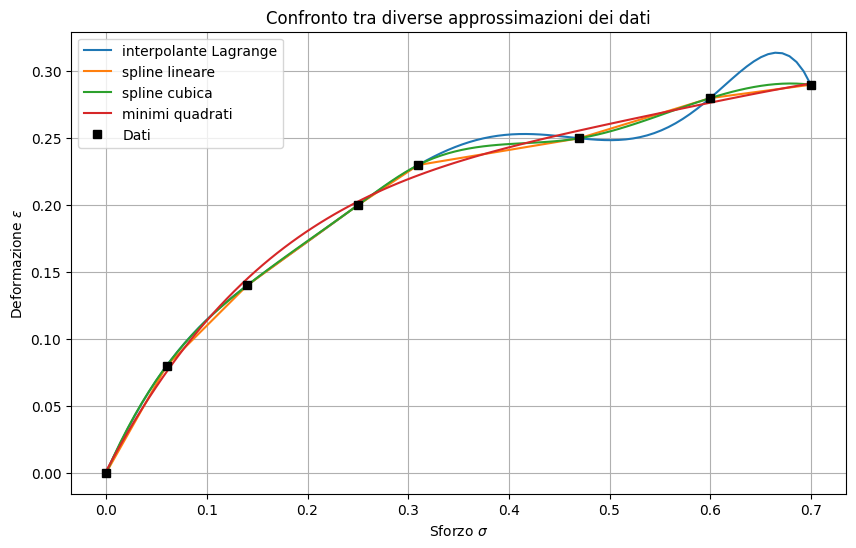

In [14]:
# Punti di valutazione
# x_grid (eventualmente ridefinire)
x_grid=np.linspace(min(sigma), max(sigma), 100)

# Confronto
plt.figure(figsize=(10,6))

# Interpolante di Lagrange
plt.plot(x_grid, interp_lagrange(x_grid), label='interpolante Lagrange')

# Spline lineare
plt.plot(x_grid, spline_lineare(x_grid), label='spline lineare')

# Spline cubica
plt.plot(x_grid, spline_cubica(x_grid), label='spline cubica')

# Minimi quadrati
plt.plot(x_grid, minq(x_grid), label='minimi quadrati')

# Dati
plt.plot(sigma, epsilon, 'ks', label='Dati')

plt.legend()
plt.title("Confronto tra diverse approssimazioni dei dati")
plt.grid()
plt.xlabel("Sforzo $\\sigma$")
plt.ylabel("Deformazione $\\varepsilon$")
plt.show()

<mark>**Esercizio 2.7: confronto approssimazioni in extra points**</mark></br>

Confrontare le approssimazioni proposte dalle tre interpolanti  e dell'approssimazione ai minimi quadrati quando $\sigma=0.4 \text{ MPa}$ e $\sigma=0.75 \text{ MPa}$, si commentino i risultati ottenuti.

In [15]:
# Stima dei valori
print("Estrapolazione in sigma=0.4 MPa")
print("Lagrange: %f" %interp_lagrange(0.4))
print("Spline lineare: %f" %spline_lineare(0.4))
print("Spline cubica: %f" %spline_cubica(0.4))
print("Minimi quadrati (grado 4): %f" %minq(0.4))
print("\n")

print("Estrapolazione in sigma=0.75 MPa")
print("Lagrange: %f" %interp_lagrange(0.75))
print("Spline lineare: %f" %spline_lineare(0.75))
print("Spline cubica: %f" %spline_cubica(0.75))
print("Minimi quadrati (grado 4): %f" %minq(0.75))



Estrapolazione in sigma=0.4 MPa
Lagrange: 0.252747
Spline lineare: 0.241250
Spline cubica: 0.245656
Minimi quadrati (grado 4): 0.243183


Estrapolazione in sigma=0.75 MPa
Lagrange: 0.080963
Spline lineare: 0.290000
Spline cubica: 0.278108
Minimi quadrati (grado 4): 0.296416


NameError: name 'psline_cubica' is not defined

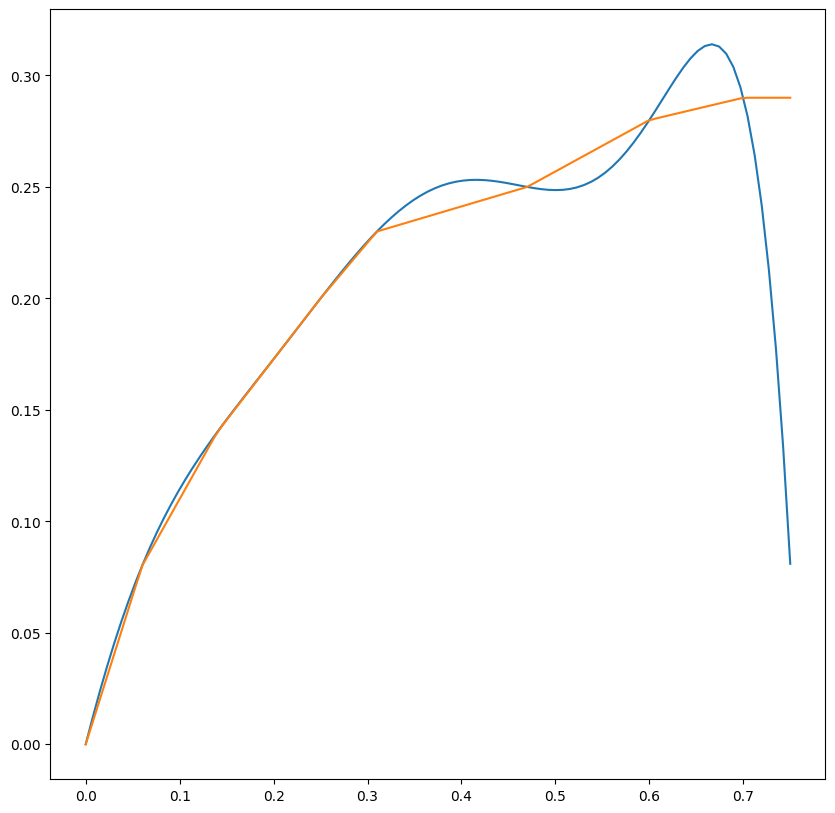

In [16]:
# Confronto grafico
#punti di valutazione
a,b=min(sigma), 0.75
x_grid=np.linspace(a,b,100)

#confronto
plt.figure(figsize=(10,10))

#interpolante di lagrange
plt.plot(x_grid, interp_lagrange(x_grid), label='interpolante di lagrange')

#spline lineare
plt.plot(x_grid, spline_lineare(x_grid), label='spline lineare')

#spline cubica
plt.plot(x_grid, psline_cubica(x_grid), label='spline cubica')

#minimi quadrati
plt.plot(x_grid, minq(x_grid), label='minimi quadrati')

dati
plt.plot(sigma, epsilon, 'ks', label='dati')
plt.plot([0.4, 0.4], [0, 0.33], 'k--', alpha=0.5)
plt.plot([0.75, 0.75], [0, 0.33], 'k--', alpha=0.5)
plt.legend()


## **Esercizi per casa**

<mark>**Esercizio 3**</mark></br>
Si consideri la funzione $f(x) = x \sin(x)$.

  1.  Si disegni  il grafico della funzione $f(x)$ nell'intervallo $[-2,6]$.
  2. Si costruiscano i polinomi interpolanti di Lagrange $\Pi_{n}f$ di grado $n=2,\,4,\,6$ relativi ad una distribuzione di nodi  equispaziati.
  3. Si rappresenti graficamente l'andamento dell'errore
$\varepsilon(x)=|f(x)-\Pi_{n}f(x)|$ e si calcoli la norma infinito:

$$
\parallel \varepsilon(x)\parallel_{\infty}=\max_{x\in[-2,6]}|f(x)-\Pi_{n}f(x)|.
$$

Commentare i risultati.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import interp, linspace, polyval, polyfit
from scipy.interpolate import CubicSpline


In [1]:
#es 3.1
f=lambda x: x*np.sin(x)
#estremi dell'intervallo
a, b=-2, 6
ascisse=linspace(a, b, 1000)
#plot
plt.plot(ascisse, f(ascisse), 'k-', label='f')

#es 3.2 - 3.3
#inizializzo le liste degli errori
err=[]
errorMax=[]

deg=[2, 4, 6]
#ciclo for
for i in deg:
    x_nodi=linspace(a, b, i+1)
    p=polyfit(x_nodi, f(x_nodi))
    interpolante = lambda x: polyval(p,x)
    plt.plot(xx,interpolante(xx), label ='poli %d' %i)
    err.append(abs(f(xx)-interpolante(xx)))
    errorMax.append(np.max(err))

plt.title("grafico della funzione $f(x)=x\sin(x)$")
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

<>:24: SyntaxWarning: invalid escape sequence '\s'
<>:24: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_12792/1584278191.py:24: SyntaxWarning: invalid escape sequence '\s'
  plt.title("grafico della funzione $f(x)=x\sin(x)$")
/tmp/ipykernel_12792/1584278191.py:24: SyntaxWarning: invalid escape sequence '\s'
  plt.title("grafico della funzione $f(x)=x\sin(x)$")


NameError: name 'linspace' is not defined

In [ ]:
plt.figure(2)
j=0
for i in deg:
plt.plot(xx,err[j], label = 'error: poli %d' %i)
j = j+1
plt.title("grafico dell'errore")
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

#Commento: Nella prima figura si possono vedere a confronto i grafici della funzione e dei polinomi
#interpolatori di grado 2, 4, 6. Nella seconda figura si osserva l’andamento dell’errore e quello che si
#può notare è che questo diminuisce all’aumentare del grado del polinomio di interpolazione. Si osserva
#che aumentando il grado del polinomio interpolatore si riesce, in questo caso, ad approssimare
#meglio la funzione richiesta.